<a href="https://colab.research.google.com/github/adit-codez/Assignment-04/blob/main/q1_supervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

# Load dataset
df = pd.read_excel("q1_heart_disease.xlsx")

# Basic inspection
print("Shape:", df.shape)
display(df.head())
print("Data types:")
print(df.dtypes)
print("Missing values:")
print(df.isnull().sum())

Shape: (800, 12)


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


Data types:
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object
Missing values:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


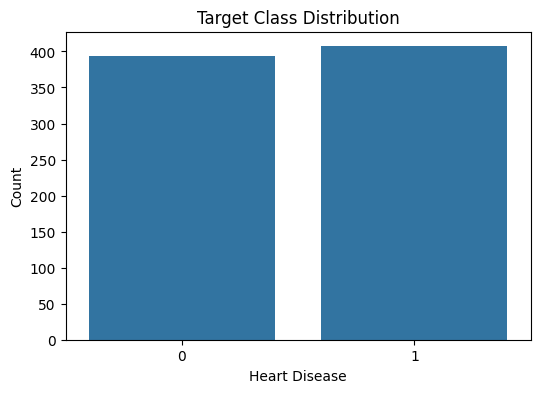

In [ ]:
# Target class distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="heart_disease")
plt.title("Target Class Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

The target class appears to show whether the dataset is balanced or imbalanced. This matters because imbalanced data can effect model performance.

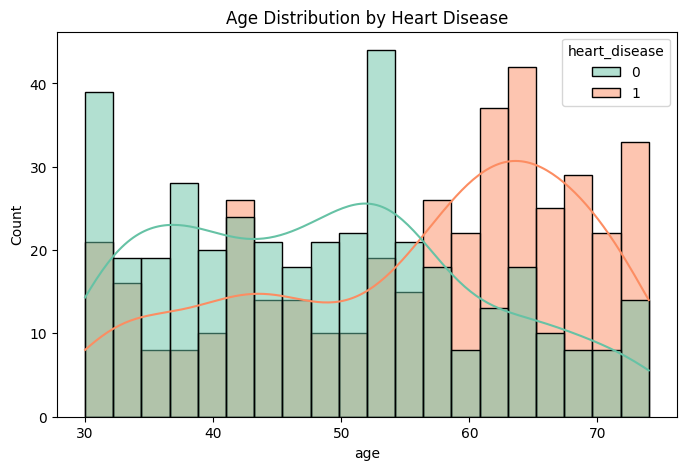

In [ ]:
# Age Distribution by target
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="age", hue="heart_disease", kde=True, bins=20, palette="Set2")
plt.title("Age Distribution by Heart Disease")
plt.show()

The age plot helps us see whether older patients have a higher concentration of heart disease cases.

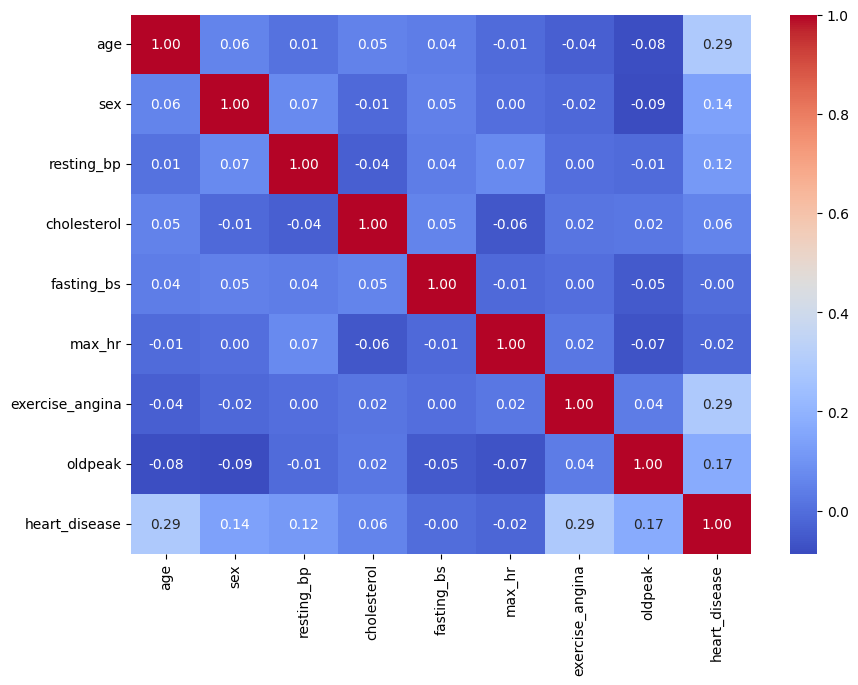

In [ ]:
# Correlation heatmap for numeric columns
plt.figure(figsize=(10,7))
numeric_cols = df.select_dtypes(include=np.number).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

The heatmap shows which numeric features are more related to the target and whether there is strong correlation between predictors.

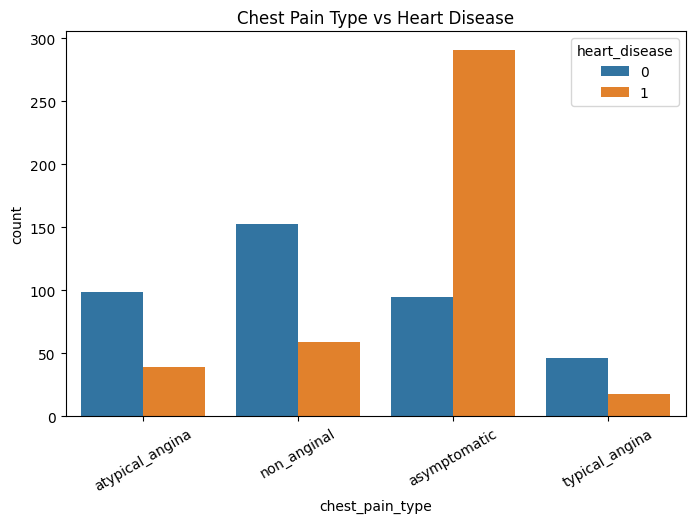

In [ ]:
# Chest pain type vs target
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="chest_pain_type", hue="heart_disease")
plt.title("Chest Pain Type vs Heart Disease")
plt.xticks(rotation=30)
plt.show()

Missing values are handled using median imputation for numeric columns because it is resistant to outliers. Categorical columns use most-frequent imputation because it preserves the most common category and avoids dropping rows.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
x = df.drop("heart_disease", axis=1)
y = df["heart_disease"]

# Identify column types
numeric_features = x.select_dtypes(include=np.number).columns.tolist()
categorical_features = x.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)


Numeric features: ['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr', 'exercise_angina', 'oldpeak']
Categorical features: ['chest_pain_type', 'resting_ecg', 'st_slope']
Train shape: (640, 11)
Test shape: (160, 11)


In [ ]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

trained_models = {}

for name, model in models.items():
    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    clf.fit(x_train, y_train)
    trained_models[name] = clf
    print(f"{name} trained successfully.")

Decision Tree trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


In [ ]:
results = []

for name, model in trained_models.items():
    y_pred = model.predict(x_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print("="*60)
    print(name)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1-score:", f1)
    print("Confusion Matrix:", cm)
    print("Classification Report:", classification_report(y_test, y_pred))

    results.append([name, acc, prec, rec, f1])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])
display(results_df)

Decision Tree
Accuracy: 0.71875
Precision: 0.7195121951219512
Recall: 0.7283950617283951
F1-score: 0.7239263803680982
Confusion Matrix: [[56 23]
 [22 59]]
Classification Report:               precision    recall  f1-score   support

           0       0.72      0.71      0.71        79
           1       0.72      0.73      0.72        81

    accuracy                           0.72       160
   macro avg       0.72      0.72      0.72       160
weighted avg       0.72      0.72      0.72       160

Random Forest
Accuracy: 0.7875
Precision: 0.7764705882352941
Recall: 0.8148148148148148
F1-score: 0.7951807228915663
Confusion Matrix: [[60 19]
 [15 66]]
Classification Report:               precision    recall  f1-score   support

           0       0.80      0.76      0.78        79
           1       0.78      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79   

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.71875,0.719512,0.728395,0.723926
1,Random Forest,0.78750,0.776471,0.814815,0.795181
2,Gradient Boosting,0.77500,0.777778,0.777778,0.777778


In [ ]:
from sklearn.model_selection import GridSearchCV

best_model_name = results_df.sort_values("F1-score", ascending=False).iloc[0]["Model"]
print("Best baseline model:", best_model_name)

Best baseline model: Random Forest


The best model is the one with the strongest balance of precision, recall, and F1-score on the test set, not just the highest accuracy. F1-score is especially important because it combines precision and recall into a single metric, so it reflects both false positives and false negatives. Based on the test metrics, the model with the highest F1-score and consistently strong precision and recall is the Random Forest model.

In [ ]:
# Tuning Block
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV Score: 0.8270360232922729


In [ ]:
# Evaluating tuned model on test set

tuned_model = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(x_test)

tuned_cm = confusion_matrix(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

print("TUNED MODEL PERFORMANCE")
print("Confusion Matrix:")
print(tuned_cm)
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall:    {tuned_recall:.4f}")
print(f"F1-score:  {tuned_f1:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_tuned))

TUNED MODEL PERFORMANCE
Confusion Matrix:
[[59 20]
 [14 67]]
Precision: 0.7701
Recall:    0.8272
F1-score:  0.7976
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.75      0.78        79
           1       0.77      0.83      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160



In [ ]:
# Compare baseline vs tuned
baseline_row = results_df[results_df["Model"] == best_model_name].iloc[0]

comparison_df = pd.DataFrame([
    {
        "Model" : f"{best_model_name} (Baseline)",
        "Precision" : baseline_row["Precision"],
        "Recall" : baseline_row["Recall"],
        "F1-score" : baseline_row["F1-score"]
    },
    {
        "Model" : f"{best_model_name} (Tuned)",
        "Precision" : tuned_precision,
        "Recall" : tuned_recall,
        "F1-score" : tuned_f1
    }
])

display(comparison_df)

,Model,Precision,Recall,F1-score
0,Random Forest (Baseline),0.776471,0.814815,0.795181
1,Random Forest (Tuned),0.770115,0.827160,0.797619


GridSearch CV was used to tune the selected model by searching over multiple hyperparameter combinations. The best parameters were selected based on cross-validation performance using F1 score. The tuned model was then evaluated on the test set and compared with the untuned baseline. If the tuned model has a higher F1 score and maintains good precision and recall, it can be considered an improvement over the baseline.  